In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 1
T2 = .5

N = 5
dim = 2
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N)

In [3]:
# creating gates
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

z_gate = qt.Qobj([[1, 0],[0, -1]])

hadamard = 1 / np.sqrt(2) * qt.Qobj([[1, 1],[1, -1]])
hada_layer = tensor(tensor([hadamard] * 3), tensor([qt.qeye(dim)] * 2))


/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_85000/745817743.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_85000/745817743.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_85000/745817743.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, 

In [4]:
# create fidelity function
# add others if you want another metric 
def hilbert_schmidt_fid_func(rho, sigma):
    return np.abs((sigma * rho).tr()) / np.sqrt((rho * rho).tr() * (sigma * sigma).tr())

In [5]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = hada_layer * cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag() * hada_layer.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]]

In [6]:
hada_layer * cnot6 * cnot5 * cnot4 * cnot3 * hada_layer * rho_encoded * hada_layer.dag() * cnot3.dag() * cnot4.dag() * cnot5.dag() * cnot6.dag() * hada_layer.dag()

Quantum object: dims = [[2, 2, 2, 2, 2], [2, 2, 2, 2, 2]], shape = (32, 32), type = oper, isherm = True
Qobj data =
[[0.125 0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]

In [7]:
# build circuit 
# CNOT gates 
states = []
fids = []
gate_times = [.025, .1, .1, .1, .1, .025]
plotting_states = []

gates = [hada_layer, cnot3, cnot4, cnot5, cnot6, hada_layer]
# CNOT gate execution
# rho_cnot = rho_encoded
# for i in range(len(gates)):
#     if i not in [0, len(gates) - 1]:
#         cnot_states = hada_layer * rho_cnot * hada_layer.dag() 
#         states.append(cnot_states)
#         if i not in [len(gates) - 1]:
#             plotting_states.append(hada_layer * cnot_states * hada_layer.dag())
#         else:
#             plotting_states.append(cnot_states)
#     else:
#         cnot_states = trotter.apply(rho_cnot, duration=.025, unitary=hada_layer)
#         states.extend(cnot_states)
#         for j in range(len(cnot_states)):
#             if i not in [len(gates) - 1]:
#                 plotting_states.append(hada_layer * cnot_states[j] * hada_layer.dag())
#             else:
#                 plotting_states.append(cnot_states[j])
#             fids.append(hilbert_schmidt_fid_func(qt.ptrace(cnot_states[j], [0,1,2]), rho_encoded_traced))
#         rho_cnot = cnot_states[-1]     


# for now will not simulate how long the hadamards take 
for i in range(len(gates)):
    if i not in [0, len(gates) - 1]:
        syndrome_application = trotter.apply(rho=rho_encoded, duration = .1, unitary=gates[i])
        states.extend(syndrome_application)
        for j in range(len(syndrome_application)):
            plotting_states.append(syndrome_application[j])
        rho_encoded = syndrome_application[-1]
    else:
        syndrome_application = hada_layer * rho_encoded * hada_layer.dag()
        if i == len(gates) - 1:
            plotting_states.append(hada_layer * syndrome_application * hada_layer.dag())
        else:
            plotting_states.append(syndrome_application)
        states.append(syndrome_application)
        rho_encoded = syndrome_application


# the current issue is that the cnots are being done in the 0 and 1 basis not the + and - basis which may contribute
# to how bad the loss is in the system

In [8]:
qt.ptrace(hada_layer * states[-1] * hada_layer.dag(), [0,1,2])
# this makes plenty of sense 
# start predicting the results before working it'll greatly help the understanding of the properties 

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[4.50805686e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 5.44212305e-03 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.44212305e-03 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 6.55190675e-02
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  5.44212305e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 6.55190675e-02 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 6.55190675e-02 0.00000000e+00]
 [0.00000000e+00 0.0000

In [9]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(z_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
duration_recovery = .001
recovery_states = []
for i in range(len(recovery_ops)):
    recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=recovery_ops[i])
    recovery_states.append(recovery)

for i in range(int(len(recovery))):
    current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
    states.append(sum(current_state)/(sum(current_state)).tr())
    plotting_states.append(hada_layer * states[-1] * hada_layer.dag())
    fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

total_time = sum(gate_times) + duration_recovery

[0.8442369039297661, 0.09874230564586037, 0.028689304389655366, 0.028331486034715588]


[0.004066947976818933, 0.0027932578289726483, 0.002153436985794665, 0.07720969362358863, 0.020920695047657416, 0.02569702657938487, 0.026625317265033758, 0.8405336246927487]


Text(0.5, 0, 'time (dt)')

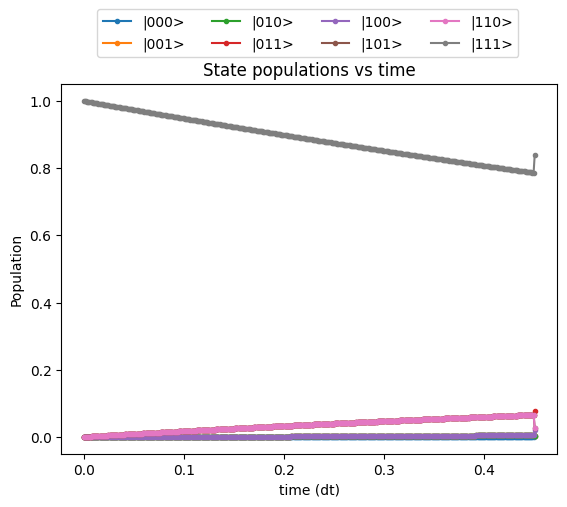

In [10]:
time = np.linspace(0, total_time, len(states))
time = np.linspace(0, total_time, len(plotting_states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    # for j in range(len(states)):
    for j in range(len(plotting_states)):
        data.append(np.real(qt.ptrace(plotting_states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")